# 프로젝트 개요 (v2 — 날씨 데이터 수집 문제 해결)

**목표:** 서울의 실제 날씨 데이터를 API로 수집하고, Oracle DB의 배달 주문 데이터와 결합해서 "비 오는 날엔 어떤 메뉴가 더 잘 팔리는지" 분석하고, 그 결과를 Gradio 화면으로 출력

**v1(`project_weather_delivery.ipynb`)에서 막혔던 지점:** 1번 날씨 데이터 수집.
- 좌표가 서울이 아니라 런던(`51.5085, -0.1257`)으로 되어 있었음
- `models: kma_seamless`(기상청 지역 모델)를 좌표 커버리지 밖에서 호출해서 대부분 `NaN`이 나왔음
- `historical-forecast-api` + `openmeteo_requests` SDK 조합이 처음 쓰기엔 복잡했음

이 파일에서는 서울 좌표로 고정하고, SDK 없이 `requests`만으로 직접 호출하는 더 단순한 방식(`archive-api.open-meteo.com`)으로 다시 구현

---

# 필수 스킬

| 단계 | 사용 기술 | 포인트 |
| :--- | :--- | :--- |
| 1. 날씨 데이터 수집 | `requests`로 외부 API 호출 (Open-Meteo, 무료·키 불필요) | 신규 — API 크롤링 |
| 2. 배달 주문 데이터 조회 | Oracle DB 연결 (`.env` + `with` 구문) | Chapter02 ex01 |
| 3. 데이터 결합 | `pd.merge()`, `groupby()`, `pivot_table()` | Chapter01, Chapter02 ex09 |
| 4. 통계 분석 | `numpy`로 상관관계, 그룹별 평균 비교 | Chapter02 ex02, ex10 |
| 5. 파일 저장 | `to_csv()`로 중간/최종 결과 저장 | 신규 (파일 저장 습관) |
| 6. 시각화 | `matplotlib` + `seaborn` (색상/라벨 커스터마이징) | Chapter02 ex03~06 |
| 7. 화면 구현 | `Gradio` 기반 UI 구축 | 신규 |


## 1. 날씨 데이터 수집

`requests`로 Open-Meteo의 과거 날씨 API(`archive-api.open-meteo.com`)를 직접 호출.
- 위경도를 **서울**(37.5665, 126.9780)로 고정
- 날짜 범위는 배달 주문 데이터가 존재하는 기간(2026-08-01 ~ 어제)에 맞춤
- 강수량(`precipitation_sum`)이 0보다 크면 `IS_RAIN = True`로 표시해서 이후 분석에 바로 쓸 수 있게 함


In [4]:
import requests
import pandas as pd
from datetime import date, timedelta

SEOUL_LAT = 37.5665
SEOUL_LON = 126.9780


def fetch_seoul_weather(start_date: str, end_date: str) -> pd.DataFrame:
    """서울 좌표 고정, Open-Meteo 과거 날씨 API를 requests로 직접 호출"""
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": SEOUL_LAT,
        "longitude": SEOUL_LON,
        "start_date": start_date,
        "end_date": end_date,
        "daily": ["weathercode", "precipitation_sum", "temperature_2m_max", "temperature_2m_min"],
        "timezone": "Asia/Seoul",
    }
    response = requests.get(url, params=params, timeout=15)
    response.raise_for_status()  # 4xx/5xx면 바로 예외 발생시켜서 조용히 실패하지 않게 함
    daily = response.json()["daily"]

    weather_df = pd.DataFrame(daily)
    weather_df.rename(columns={"time": "WEATHER_DATE"}, inplace=True)
    weather_df["WEATHER_DATE"] = pd.to_datetime(weather_df["WEATHER_DATE"])
    weather_df["IS_RAIN"] = weather_df["precipitation_sum"] > 0
    return weather_df


# 주문 데이터가 존재하는 기간만큼 조회 (DELIVERY_ORDERS 기준 2026-08-01부터 시작)
start_date = "2026-08-01"
end_date = (date.today() - timedelta(days=1)).isoformat()

weather_df = fetch_seoul_weather(start_date, end_date)
print(f"서울 날씨 데이터 {len(weather_df)}일치 수집 완료 ({start_date} ~ {end_date})")
weather_df.head()


서울 날씨 데이터 33일치 수집 완료 (2026-08-01 ~ 2026-09-02)


,WEATHER_DATE,weathercode,precipitation_sum,temperature_2m_max,temperature_2m_min,IS_RAIN
0,2026-08-01,53,2.2,32.8,26.1,True
1,2026-08-02,3,0.0,34.1,26.3,False
2,2026-08-03,51,0.1,37.2,25.3,True
3,2026-08-04,55,2.7,36.6,28.7,True
4,2026-08-05,61,5.7,37.5,26.8,True


In [5]:
# 중간 결과 저장
weather_df.to_csv("data/seoul_weather.csv", index=False, encoding="utf-8-sig")
print("날씨 데이터 저장 완료: data/seoul_weather.csv")


날씨 데이터 저장 완료: data/seoul_weather.csv


## 2. 배달 주문 데이터 조회 (Oracle DB)

In [6]:
import os
from dotenv import load_dotenv
import oracledb

load_dotenv()
USER = os.getenv("ORACLE_USER")
PASSWORD = os.getenv("ORACLE_PASSWORD")
DSN = os.getenv("ORACLE_DSN")

with oracledb.connect(user=USER, password=PASSWORD, dsn=DSN) as conn:
    orders_df = pd.read_sql("SELECT * FROM DELIVERY_ORDERS", conn)
# with문 블록을 벗어나는 순간 자동으로 conn.close()가 호출되어 안정적임

print("연결 및 쿼리 성공! 데이터 shape:", orders_df.shape)
orders_df.head()


연결 및 쿼리 성공! 데이터 shape: (68, 7)


C:\Users\Nopen\AppData\Local\Temp\ipykernel_14548\521243853.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  orders_df = pd.read_sql("SELECT * FROM DELIVERY_ORDERS", conn)


,ORDER_ID,MENU_NAME,CATEGORY,PRICE,RATING,REGION,ORDER_DATE
0,41,떡볶이,분식,8800,4.4,강남구,2026-08-23
1,42,김밥,분식,5200,4.2,서초구,2026-08-23
2,43,순대,분식,7200,4.0,송파구,2026-08-23
3,44,돈까스,일식,11500,4.4,강남구,2026-08-23
4,45,떡볶이,분식,9200,4.5,강남구,2026-08-24


## 3. 데이터 결합

주문 날짜(`ORDER_DATE`)와 날씨 날짜(`WEATHER_DATE`)를 기준으로 `pd.merge()`

In [7]:
merged_df = pd.merge(
    orders_df,
    weather_df,
    left_on="ORDER_DATE",
    right_on="WEATHER_DATE",
    how="inner",
)
print("결합 후 shape:", merged_df.shape)
merged_df.head()


결합 후 shape: (68, 13)


,ORDER_ID,MENU_NAME,CATEGORY,PRICE,RATING,REGION,ORDER_DATE,WEATHER_DATE,weathercode,precipitation_sum,temperature_2m_max,temperature_2m_min,IS_RAIN
0,41,떡볶이,분식,8800,4.4,강남구,2026-08-23,2026-08-23,63,9.2,32.1,22.5,True
1,42,김밥,분식,5200,4.2,서초구,2026-08-23,2026-08-23,63,9.2,32.1,22.5,True
2,43,순대,분식,7200,4.0,송파구,2026-08-23,2026-08-23,63,9.2,32.1,22.5,True
3,44,돈까스,일식,11500,4.4,강남구,2026-08-23,2026-08-23,63,9.2,32.1,22.5,True
4,45,떡볶이,분식,9200,4.5,강남구,2026-08-24,2026-08-24,51,0.5,31.4,24.6,True


## 4. 통계 분석

비/맑음 그룹별 평균 비교, 강수량-가격 상관관계, 카테고리별 '비 오는 날' 주문 비율

In [8]:
import numpy as np

rain_summary = merged_df.groupby("IS_RAIN").agg(
    주문건수=("ORDER_ID", "count"),
    평균가격=("PRICE", "mean"),
    평균평점=("RATING", "mean"),
).round(1)
print("비/맑음 그룹별 요약")
print(rain_summary)

corr = np.corrcoef(merged_df["precipitation_sum"], merged_df["PRICE"])[0, 1]
print(f"\n강수량 vs 가격 상관계수: {corr:.3f}")


비/맑음 그룹별 요약
         주문건수     평균가격  평균평점
IS_RAIN                     
False       6  17083.3   4.3
True       62  15680.6   4.4

강수량 vs 가격 상관계수: -0.199


In [9]:
category_rain_pivot = pd.pivot_table(
    merged_df,
    values="ORDER_ID",
    index="CATEGORY",
    columns="IS_RAIN",
    aggfunc="count",
    fill_value=0,
)
category_rain_pivot.columns = ["맑음", "비"]
category_rain_pivot["비_비율(%)"] = (
    category_rain_pivot["비"] / category_rain_pivot.sum(axis=1) * 100
).round(1)

category_rain_pivot.sort_values("비_비율(%)", ascending=False)


,맑음,비,비_비율(%)
CATEGORY,,,
분식,0,19,100.0
일식,1,13,92.9
치킨,1,13,92.9
피자,2,9,81.8
중식,2,8,80.0


## 5. 파일 저장 (최종 결과)

In [10]:
merged_df.to_csv("data/weather_delivery_merged.csv", index=False, encoding="utf-8-sig")
category_rain_pivot.to_csv("data/category_rain_ratio.csv", encoding="utf-8-sig")
print("최종 결과 저장 완료: data/weather_delivery_merged.csv, data/category_rain_ratio.csv")


최종 결과 저장 완료: data/weather_delivery_merged.csv, data/category_rain_ratio.csv


## 6. 시각화

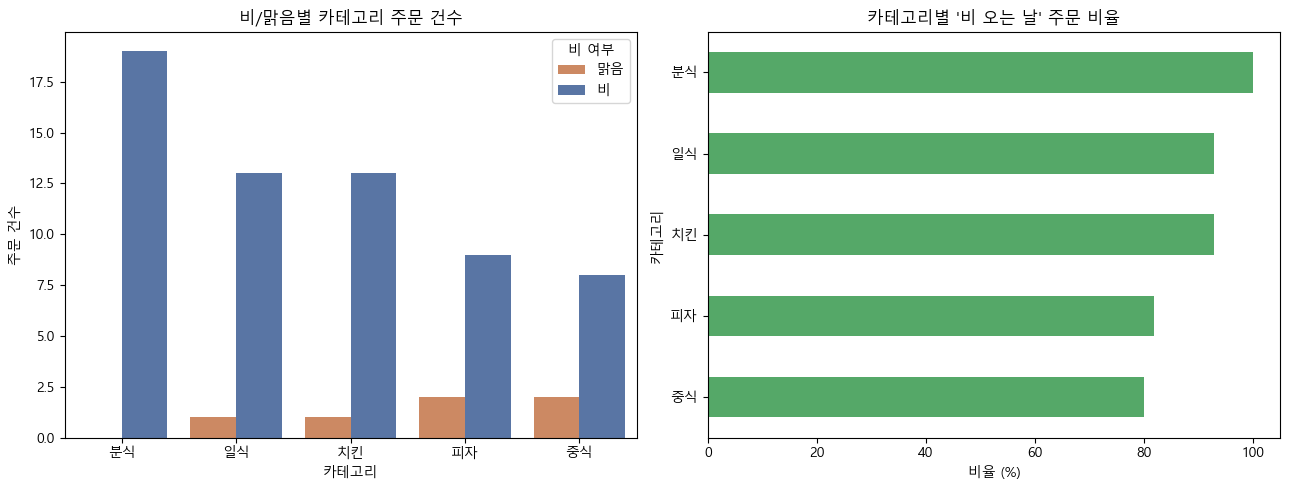

In [11]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

mpl.rc("font", family="Malgun Gothic")
mpl.rc("axes", unicode_minus=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.countplot(
    data=merged_df, x="CATEGORY", hue="IS_RAIN", ax=axes[0],
    palette={True: "#4C72B0", False: "#DD8452"},
)
axes[0].set_title("비/맑음별 카테고리 주문 건수")
axes[0].set_xlabel("카테고리")
axes[0].set_ylabel("주문 건수")
axes[0].legend(title="비 여부", labels=["맑음", "비"])

category_rain_pivot["비_비율(%)"].sort_values().plot(
    kind="barh", ax=axes[1], color="#55A868"
)
axes[1].set_title("카테고리별 '비 오는 날' 주문 비율")
axes[1].set_xlabel("비율 (%)")
axes[1].set_ylabel("카테고리")

plt.tight_layout()
plt.show()


## 7. 화면 구현 (Gradio)

날씨(맑음/비)를 고르면 실제 주문 데이터 기준 인기 메뉴 TOP 5를 보여주는 간단한 UI

In [15]:
import gradio as gr


def recommend_by_weather(is_rain: str):
    rain_flag = (is_rain == "비")
    subset = merged_df[merged_df["IS_RAIN"] == rain_flag]
    if subset.empty:
        return "해당 조건의 주문 데이터가 없습니다."

    top = (
        subset.groupby("MENU_NAME")["ORDER_ID"]
        .count()
        .sort_values(ascending=False)
        .head(5)
    )
    lines = [f"{i + 1}. {menu} ({cnt}건)" for i, (menu, cnt) in enumerate(top.items())]
    return "\n".join(lines)


demo = gr.Interface(
    fn=recommend_by_weather,
    inputs=gr.Radio(["맑음", "비"], label="날씨", value="비"),
    outputs=gr.Textbox(label="인기 메뉴 TOP 5"),
    title="날씨별 배달 메뉴 추천",
    description="서울 날씨(강수 여부)에 따라 실제 주문 데이터 기반 인기 메뉴를 보여줍니다.",
)


In [16]:
demo.launch()


Running on local URL:  http://127.0.0.1:7860

To create a public link, set `share=True` in `launch()`.


In [14]:
demo.close()

Closing server running on port: 7860
